# Model Selection — Admisiones de Posgrado

**Autor:** SCO  
**Fecha:** 2026-08-20  
**Issue:** #6 — Model Selection

Este notebook implementa selección manual de modelos de regresión. El objetivo es
seleccionar un modelo que supere el baseline principal `CGPA band heuristic` con un
proceso reproducible y sin data leakage.

Se elige el enfoque manual, no AutoML, porque el Issue exige documentar explícitamente
la evaluación inicial, el filtrado, la optimización, Nested Cross Validation, pruebas
estadísticas, learning curve, escalabilidad, serialización e interpretación. El dataset
tiene 471 registros únicos, por lo que este proceso es viable y permite controlar cada
decisión metodológica.

**Regla de evaluación:** el Test permanece intacto hasta el final. Los hiperparámetros
se seleccionan dentro de Inner CV y los modelos tuneados se comparan con Outer CV.


## 📚 Import libraries

Las métricas principales son RMSE, MAE y R². RMSE es la métrica primaria definida en
Issues anteriores porque mantiene las unidades del target y penaliza más los errores
grandes.


In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy import stats
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.validation import check_is_fitted

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("scipy:", scipy.__version__)
print("joblib:", joblib.__version__)

Python: 3.12.13
pandas: 3.0.5
NumPy: 2.5.2
scikit-learn: 1.9.0
scipy: 1.18.0
joblib: 1.5.3


## 💾 Load and validate data

The Parquet is read without modifying RAW or the intermediate source. Exact duplicates
are removed in memory before the split, as required by the leakage audit and Issues #4/#5.


In [2]:
def find_repo_root(start: Path) -> Path:
    """Locate the repository root by searching for pyproject.toml."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find the repository root.")


ROOT = find_repo_root(Path.cwd())
DATA_PATH = ROOT / "data" / "02_intermediate" / "Admission_Predict.parquet"
MODEL_PATH = ROOT / "models" / "05_model_selection_pipeline.joblib"

target = "Chance of Admit"
expected_columns = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
    target,
]

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

admission_df = pd.read_parquet(DATA_PATH)
assert list(admission_df.columns) == expected_columns
assert admission_df[target].notna().all()
assert admission_df[target].between(0.0, 1.0).all()

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Initial shape: {admission_df.shape}")
print("Missing values by column:")
print(admission_df.isna().sum().to_string())

Dataset loaded from: /home/elkiruvi/Proyecto-Admisiones/data/02_intermediate/Admission_Predict.parquet
Initial shape: (623, 8)
Missing values by column:
GRE Score            11
TOEFL Score          19
University Rating     6
SOP                  16
LOR                   8
CGPA                  2
Research             29
Chance of Admit       0


In [3]:
initial_rows = len(admission_df)
n_duplicates = int(admission_df.duplicated().sum())
admission_unique_df = admission_df.drop_duplicates().reset_index(drop=True)
unique_rows = len(admission_unique_df)

assert unique_rows == initial_rows - n_duplicates
assert not admission_unique_df.duplicated().any()

numeric_features = ["GRE Score", "TOEFL Score", "CGPA"]
ordinal_features = ["University Rating", "SOP", "LOR"]
binary_features = ["Research"]
feature_columns = numeric_features + ordinal_features + binary_features

X = admission_unique_df[feature_columns]
y = admission_unique_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

assert (initial_rows, n_duplicates, unique_rows) == (623, 152, 471)
assert (len(X_train), len(X_test)) == (376, 95)
assert set(X_train.index).isdisjoint(set(X_test.index))

print(f"Initial rows: {initial_rows}")
print(f"Exact duplicates removed before split: {n_duplicates}")
print(f"Unique rows: {unique_rows}")
print(f"Train shape: {X_train.shape}, target: {y_train.shape}")
print(f"Test shape: {X_test.shape}, target: {y_test.shape}")
print("Test has not been used for preprocessing, selection, or tuning.")

Initial rows: 623
Exact duplicates removed before split: 152
Unique rows: 471
Train shape: (376, 7), target: (376,)
Test shape: (95, 7), target: (95,)
Test has not been used for preprocessing, selection, or tuning.


## 🔧 Preprocessing and baseline

The preprocessing is reconstructed from Issue #4/#5 and remains unfitted here. Every
candidate model gets a fresh `Pipeline` containing this preprocessing and its estimator.
Therefore, during CV, imputation and scaling are learned only from each fold's training
portion.

The `CGPA band heuristic` remains the explicit primary baseline throughout the process.
The historical Issue #5 results are context only; the baseline is re-evaluated below with
the same Outer CV used for the finalists. Its historical Test RMSE is retained only as a
final reference because Test must not be evaluated before the final model.


In [4]:
MIN_FINALIST_COUNT = 2
MAX_FINALIST_COUNT = 3
SIGNIFICANCE_LEVEL = 0.05

# Screening uses folds independent of the outer evaluation to avoid
# selection-then-evaluation bias on identical partitions.
SCREENING_CV_RANDOM_STATE = 123

ordinal_categories = [
    [1, 2, 3, 4, 5],
    [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
]


def build_preprocessor() -> ColumnTransformer:
    """Build the unfitted Issue #4 preprocessing transformer."""
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    ordinal_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(categories=ordinal_categories)),
            ("scaler", StandardScaler()),
        ]
    )
    binary_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))])
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("ordinal", ordinal_pipeline, ordinal_features),
            ("binary", binary_pipeline, binary_features),
        ]
    )


class CGPABinnedMeanRegressor(BaseEstimator, RegressorMixin):
    """Predict the training target mean for fixed CGPA bands."""

    EXPECTED_INPUT_DIM = 2
    EXPECTED_FEATURE_COUNT = 1
    MIN_BIN_EDGE_COUNT = 2

    def __init__(self, bin_edges=(0.0, 8.5, 9.0, np.inf)):
        self.bin_edges = bin_edges

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        if X.ndim != self.EXPECTED_INPUT_DIM or X.shape[1] != self.EXPECTED_FEATURE_COUNT:
            raise ValueError("CGPA heuristic expects exactly one feature.")
        if len(self.bin_edges) < self.MIN_BIN_EDGE_COUNT or not np.all(np.diff(self.bin_edges) > 0):
            raise ValueError("bin_edges must be strictly increasing.")
        self.global_mean_ = float(np.mean(y))
        bin_ids = np.digitize(X[:, 0], self.bin_edges[1:-1], right=False)
        self.bin_means_ = np.array(
            [
                float(np.mean(y[bin_ids == bin_id]))
                if np.any(bin_ids == bin_id)
                else self.global_mean_
                for bin_id in range(len(self.bin_edges) - 1)
            ]
        )
        return self

    def predict(self, X):
        check_is_fitted(self, ["global_mean_", "bin_means_"])
        X = np.asarray(X, dtype=float)
        if X.ndim != self.EXPECTED_INPUT_DIM or X.shape[1] != self.EXPECTED_FEATURE_COUNT:
            raise ValueError("CGPA heuristic expects exactly one feature.")
        bin_ids = np.digitize(X[:, 0], self.bin_edges[1:-1], right=False)
        return self.bin_means_[bin_ids]


baseline_pipeline = Pipeline(
    steps=[
        (
            "cgpa_preprocessor",
            ColumnTransformer(
                transformers=[("cgpa", SimpleImputer(strategy="median"), ["CGPA"])],
                remainder="drop",
            ),
        ),
        ("model", CGPABinnedMeanRegressor()),
    ]
)

historical_baseline_cv_rmse = 0.0902
historical_baseline_test_rmse = 0.0919
print("Historical Issue #5 baseline CV RMSE: 0.0902")
print("Historical Issue #5 baseline Test RMSE: 0.0919")
print("Preprocessors are unfitted before CV:", not hasattr(build_preprocessor(), "transformers_"))

Historical Issue #5 baseline CV RMSE: 0.0902
Historical Issue #5 baseline Test RMSE: 0.0919
Preprocessors are unfitted before CV: True


## 🧪 Candidate models

The initial set contains at least five methodological families: ordinary linear
regression, regularized linear regression, instance-based regression, decision trees,
bagging ensembles and boosting ensembles. L1/L2 are not presented as separate artificial
families; they are regularization variants within the linear family.


In [5]:
def make_pipeline(model) -> Pipeline:
    """Wrap a fresh Issue #4 preprocessor and estimator in one Pipeline."""
    return Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("model", model),
        ]
    )


candidate_models = {
    "LinearRegression": make_pipeline(LinearRegression()),
    "Ridge": make_pipeline(Ridge()),
    "Lasso": make_pipeline(Lasso(max_iter=20_000)),
    "ElasticNet": make_pipeline(ElasticNet(max_iter=20_000)),
    "KNeighborsRegressor": make_pipeline(KNeighborsRegressor()),
    "DecisionTreeRegressor": make_pipeline(DecisionTreeRegressor(random_state=42)),
    "RandomForestRegressor": make_pipeline(RandomForestRegressor(random_state=42)),
    "GradientBoostingRegressor": make_pipeline(GradientBoostingRegressor(random_state=42)),
}

for _name, pipeline in candidate_models.items():
    assert isinstance(pipeline, Pipeline)
    assert "preprocessor" in pipeline.named_steps
    assert "model" in pipeline.named_steps

print("Candidate models:")
for name, pipeline in candidate_models.items():
    print(f" - {name}: {pipeline.named_steps['model'].__class__.__name__}")

Candidate models:
 - LinearRegression: LinearRegression
 - Ridge: Ridge
 - Lasso: Lasso
 - ElasticNet: ElasticNet
 - KNeighborsRegressor: KNeighborsRegressor
 - DecisionTreeRegressor: DecisionTreeRegressor
 - RandomForestRegressor: RandomForestRegressor
 - GradientBoostingRegressor: GradientBoostingRegressor


## 📏 Initial evaluation with Cross Validation

All eight candidates are evaluated with the same 5-fold split on `X_train`. The Test set
is not passed to this operation. RMSE is primary; MAE and R² are complementary.

The screening folds are drawn independently from the Outer CV folds (Issue #41):
selection and evaluation must not reuse the same partitions.


In [6]:
cv_initial = KFold(n_splits=5, shuffle=True, random_state=SCREENING_CV_RANDOM_STATE)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}


def positive_scores(results: dict) -> dict:
    return {
        "rmse": -results["test_rmse"],
        "mae": -results["test_mae"],
        "r2": results["test_r2"],
    }


initial_results = {}
initial_fold_rows = []
initial_summary_rows = []

for model_name, pipeline in candidate_models.items():
    results = cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv_initial,
        return_train_score=False,
        n_jobs=1,
        error_score="raise",
    )
    initial_results[model_name] = results
    scores = positive_scores(results)
    for fold, (rmse, mae, r2) in enumerate(
        zip(scores["rmse"], scores["mae"], scores["r2"], strict=True),
        start=1,
    ):
        initial_fold_rows.append(
            {"Model": model_name, "Fold": fold, "RMSE": rmse, "MAE": mae, "R2": r2}
        )
    initial_summary_rows.append(
        {
            "Model": model_name,
            "CV RMSE mean": scores["rmse"].mean(),
            "CV RMSE std": scores["rmse"].std(ddof=1),
            "CV MAE mean": scores["mae"].mean(),
            "CV MAE std": scores["mae"].std(ddof=1),
            "CV R2 mean": scores["r2"].mean(),
            "CV R2 std": scores["r2"].std(ddof=1),
            "Fit time mean": results["fit_time"].mean(),
            "Fit time std": results["fit_time"].std(ddof=1),
            "Score time mean": results["score_time"].mean(),
            "Score time std": results["score_time"].std(ddof=1),
        }
    )

initial_fold_results = pd.DataFrame(initial_fold_rows)
initial_summary = (
    pd.DataFrame(initial_summary_rows).sort_values("CV RMSE mean").reset_index(drop=True)
)

print("Initial fold-level results:")
display(initial_fold_results.round(4))
print("Initial CV summary (mean and sample standard deviation, ddof=1):")
display(initial_summary.round(4))

Initial fold-level results:


,Model,Fold,RMSE,MAE,R2
0,LinearRegression,1,0.0569,0.0429,0.8346
1,LinearRegression,2,0.0707,0.0511,0.6854
2,LinearRegression,3,0.0678,0.0479,0.7880
3,LinearRegression,4,0.0597,0.0443,0.8193
4,LinearRegression,5,0.0645,0.0457,0.8273
5,Ridge,1,0.0569,0.0429,0.8344
6,Ridge,2,0.0707,0.0510,0.6862
7,Ridge,3,0.0678,0.0478,0.7884
8,Ridge,4,0.0596,0.0442,0.8198
9,Ridge,5,0.0646,0.0458,0.8269


Initial CV summary (mean and sample standard deviation, ddof=1):


,Model,CV RMSE mean,CV RMSE std,CV MAE mean,CV MAE std,CV R2 mean,CV R2 std,Fit time mean,Fit time std,Score time mean,Score time std
0,Ridge,0.0639,0.0057,0.0463,0.0032,0.7911,0.0612,0.0347,0.0037,0.0188,0.0027
1,LinearRegression,0.0639,0.0057,0.0464,0.0032,0.7909,0.0616,0.0413,0.0156,0.0214,0.0031
2,RandomForestRegressor,0.0659,0.0051,0.0461,0.0023,0.7791,0.0555,0.2328,0.0142,0.0267,0.0044
3,GradientBoostingRegressor,0.0674,0.0048,0.0485,0.0030,0.7684,0.0594,0.1347,0.0061,0.0190,0.0020
4,KNeighborsRegressor,0.0683,0.0042,0.0486,0.0026,0.7621,0.0639,0.0343,0.0037,0.0419,0.0478
5,DecisionTreeRegressor,0.0893,0.0100,0.0614,0.0039,0.5958,0.1019,0.0351,0.0025,0.0196,0.0029
6,ElasticNet,0.1420,0.0107,0.1142,0.0107,-0.0031,0.0019,0.0335,0.0048,0.0170,0.0025
7,Lasso,0.1420,0.0107,0.1142,0.0107,-0.0031,0.0019,0.0337,0.0022,0.0180,0.0010


## ✂️ Academic filtering rule

The requirement is applied literally using primary metric RMSE, where lower is better:

```text
avg_rmse = average of the eight candidate CV RMSE means
eliminate if candidate CV RMSE mean > avg_rmse
keep if candidate CV RMSE mean <= avg_rmse
```

The 2–3 finalists are the best survivors by CV RMSE. This filtering is performed only
with training-fold validation results.


In [7]:
avg_rmse = float(initial_summary["CV RMSE mean"].mean())
survivor_summary = initial_summary[initial_summary["CV RMSE mean"] <= avg_rmse].copy()
eliminated_summary = initial_summary[initial_summary["CV RMSE mean"] > avg_rmse].copy()

assert len(survivor_summary) >= MIN_FINALIST_COUNT, (
    "The academic filter must leave at least two finalists."
)
finalist_names = survivor_summary.nsmallest(MAX_FINALIST_COUNT, "CV RMSE mean")["Model"].tolist()
finalists = {name: candidate_models[name] for name in finalist_names}

print(f"Average candidate CV RMSE: {avg_rmse:.4f}")
print("Eliminated models (CV RMSE mean > average):", eliminated_summary["Model"].tolist())
print("Survivors (CV RMSE mean <= average):", survivor_summary["Model"].tolist())
print("Finalists selected for Nested CV:", finalist_names)
display(survivor_summary.round(4))

Average candidate CV RMSE: 0.0879
Eliminated models (CV RMSE mean > average): ['DecisionTreeRegressor', 'ElasticNet', 'Lasso']
Survivors (CV RMSE mean <= average): ['Ridge', 'LinearRegression', 'RandomForestRegressor', 'GradientBoostingRegressor', 'KNeighborsRegressor']
Finalists selected for Nested CV: ['Ridge', 'LinearRegression', 'RandomForestRegressor']


,Model,CV RMSE mean,CV RMSE std,CV MAE mean,CV MAE std,CV R2 mean,CV R2 std,Fit time mean,Fit time std,Score time mean,Score time std
0,Ridge,0.0639,0.0057,0.0463,0.0032,0.7911,0.0612,0.0347,0.0037,0.0188,0.0027
1,LinearRegression,0.0639,0.0057,0.0464,0.0032,0.7909,0.0616,0.0413,0.0156,0.0214,0.0031
2,RandomForestRegressor,0.0659,0.0051,0.0461,0.0023,0.7791,0.0555,0.2328,0.0142,0.0267,0.0044
3,GradientBoostingRegressor,0.0674,0.0048,0.0485,0.0030,0.7684,0.0594,0.1347,0.0061,0.0190,0.0020
4,KNeighborsRegressor,0.0683,0.0042,0.0486,0.0026,0.7621,0.0639,0.0343,0.0037,0.0419,0.0478


### Limitación metodológica del filtrado: Lasso y ElasticNet no fueron afinadosNota de transparencia sobre la criba académica (no cambia ninguna decisión):- `Lasso` y `ElasticNet` fueron evaluados en la criba inicial con su hiperparámetro por defecto (`alpha=1.0`).- Con ese `alpha`, ambos redujeron todos sus coeficientes a cero y obtuvieron un RMSE de validación cruzada prácticamente igual al del `DummyRegressor` (~0.1423).- La regla académica de filtrado se aplica antes de afinar hiperparámetros, por lo que ambos quedaron eliminados en esa etapa.- Sus grillas de afinamiento sí fueron definidas en este notebook, pero nunca se ejecutaron para los modelos eliminados.- Por lo tanto, este proyecto NO afirma que `Lasso`/`ElasticNet` afinados sean inferiores a los finalistas: simplemente no fueron afinados dentro de este flujo.- Esta es una limitación de transparencia/alcance del diseño de cribado prescrito, no un defecto del modelo final seleccionado.

## 🔁 Nested Cross Validation for finalists

For each finalist, `GridSearchCV` performs hyperparameter selection only inside Inner CV.
The complete GridSearchCV estimator is then evaluated by Outer CV. The external fold
scores, not the inner scores, are used for final performance comparison and statistical
tests.


In [8]:
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=7)

# Issue #41: screening and outer evaluation must not share any fold.
screening_splits = list(cv_initial.split(X_train))
outer_splits = list(outer_cv.split(X_train))
assert not any(
    np.array_equal(screening_train, outer_train)
    for screening_train, _ in screening_splits
    for outer_train, _ in outer_splits
), "Screening and outer CV must not reuse any identical fold."

param_grids = {
    "LinearRegression": {},
    "Ridge": {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    "Lasso": {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]},
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1.0],
        "model__l1_ratio": [0.25, 0.5, 0.75],
    },
    "KNeighborsRegressor": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
    },
    "DecisionTreeRegressor": {
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "RandomForestRegressor": {
        "model__n_estimators": [100, 300],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_leaf": [1, 2],
    },
    "GradientBoostingRegressor": {
        "model__n_estimators": [100, 300],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3],
    },
}

nested_results = {}
nested_fold_rows = []

for model_name in finalist_names:
    inner_estimator = GridSearchCV(
        estimator=clone(finalists[model_name]),
        param_grid=param_grids[model_name],
        scoring="neg_root_mean_squared_error",
        cv=inner_cv,
        n_jobs=1,
        error_score="raise",
        refit=True,
    )
    results = cross_validate(
        inner_estimator,
        X_train,
        y_train,
        scoring=scoring,
        cv=outer_cv,
        return_train_score=True,
        return_estimator=True,
        n_jobs=1,
        error_score="raise",
    )
    nested_results[model_name] = results
    for fold, (estimator, train_rmse, rmse, mae, r2, fit_time, score_time) in enumerate(
        zip(
            results["estimator"],
            -results["train_rmse"],
            -results["test_rmse"],
            -results["test_mae"],
            results["test_r2"],
            results["fit_time"],
            results["score_time"],
            strict=True,
        ),
        start=1,
    ):
        nested_fold_rows.append(
            {
                "Model": model_name,
                "Outer Fold": fold,
                "Best Params": estimator.best_params_,
                "Inner CV RMSE": -estimator.best_score_,
                "Train RMSE": train_rmse,
                "Outer RMSE": rmse,
                "Outer MAE": mae,
                "Outer R2": r2,
                "Fit time": fit_time,
                "Score time": score_time,
            }
        )

nested_fold_results = pd.DataFrame(nested_fold_rows)
nested_summary = (
    nested_fold_results.groupby("Model", as_index=False)
    .agg(
        **{
            "Outer CV RMSE mean": ("Outer RMSE", "mean"),
            "Outer CV RMSE std": ("Outer RMSE", "std"),
            "Outer CV MAE mean": ("Outer MAE", "mean"),
            "Outer CV MAE std": ("Outer MAE", "std"),
            "Outer CV R2 mean": ("Outer R2", "mean"),
            "Outer CV R2 std": ("Outer R2", "std"),
            "Outer Train RMSE mean": ("Train RMSE", "mean"),
            "Mean Fit Time": ("Fit time", "mean"),
            "Fit Time Std": ("Fit time", "std"),
            "Mean Score Time": ("Score time", "mean"),
            "Score Time Std": ("Score time", "std"),
        }
    )
    .sort_values("Outer CV RMSE mean")
    .reset_index(drop=True)
)

print("Nested CV per-outer-fold results:")
display(nested_fold_results.round(4))
print("Nested CV summary; all standard deviations use ddof=1:")
display(nested_summary.round(4))

Nested CV per-outer-fold results:


,Model,Outer Fold,Best Params,Inner CV RMSE,Train RMSE,Outer RMSE,Outer MAE,Outer R2,Fit time,Score time
0,Ridge,1,{'model__alpha': 10.0},0.0657,0.0644,0.0545,0.0399,0.8084,1.0793,0.0158
1,Ridge,2,{'model__alpha': 1.0},0.0649,0.0638,0.0575,0.0414,0.8546,1.0866,0.0146
2,Ridge,3,{'model__alpha': 10.0},0.0623,0.0611,0.0709,0.0502,0.7958,1.0552,0.0145
3,Ridge,4,{'model__alpha': 10.0},0.0622,0.0612,0.0684,0.0487,0.7687,1.3988,0.0178
4,Ridge,5,{'model__alpha': 10.0},0.0621,0.0607,0.0705,0.0531,0.7076,1.1618,0.0181
5,LinearRegression,1,{},0.0661,0.0643,0.0553,0.0402,0.8027,0.2455,0.0144
6,LinearRegression,2,{},0.0649,0.0638,0.0577,0.0415,0.8537,0.2424,0.0132
7,LinearRegression,3,{},0.0625,0.0610,0.0700,0.0500,0.8010,0.2447,0.0136
8,LinearRegression,4,{},0.0622,0.0611,0.0688,0.0493,0.7663,0.2317,0.0163
9,LinearRegression,5,{},0.0623,0.0606,0.0705,0.0531,0.7075,0.2423,0.0161


Nested CV summary; all standard deviations use ddof=1:


,Model,Outer CV RMSE mean,Outer CV RMSE std,Outer CV MAE mean,Outer CV MAE std,Outer CV R2 mean,Outer CV R2 std,Outer Train RMSE mean,Mean Fit Time,Fit Time Std,Mean Score Time,Score Time Std
0,Ridge,0.0644,0.0078,0.0466,0.0057,0.7870,0.0542,0.0622,1.1564,0.1413,0.0162,0.0017
1,LinearRegression,0.0645,0.0073,0.0468,0.0056,0.7863,0.0539,0.0622,0.2413,0.0056,0.0147,0.0014
2,RandomForestRegressor,0.0681,0.0056,0.0481,0.0032,0.7649,0.0290,0.0395,27.4632,2.5318,0.0481,0.0212


## 📌 Baseline re-evaluation with the same Outer CV

The baseline is evaluated on the same five outer folds as the finalists. This creates a
comparable training-only reference. The historical Test result from Issue #5 is retained
as context only; Test is not re-evaluated for the baseline here.


In [9]:
baseline_outer_results = cross_validate(
    clone(baseline_pipeline),
    X_train,
    y_train,
    scoring=scoring,
    cv=outer_cv,
    return_train_score=True,
    n_jobs=1,
    error_score="raise",
)

baseline_outer_rmse = -baseline_outer_results["test_rmse"]
baseline_outer_mae = -baseline_outer_results["test_mae"]
baseline_outer_r2 = baseline_outer_results["test_r2"]
baseline_outer_summary = pd.DataFrame(
    {
        "Metric": ["RMSE", "MAE", "R2"],
        "Outer CV mean": [
            baseline_outer_rmse.mean(),
            baseline_outer_mae.mean(),
            baseline_outer_r2.mean(),
        ],
        "Outer CV std ddof=1": [
            baseline_outer_rmse.std(ddof=1),
            baseline_outer_mae.std(ddof=1),
            baseline_outer_r2.std(ddof=1),
        ],
        "Historical Issue #5": [historical_baseline_cv_rmse, 0.0705, 0.5870],
    }
)
baseline_fold_results = pd.DataFrame(
    {
        "Outer Fold": np.arange(1, outer_cv.get_n_splits() + 1),
        "RMSE": baseline_outer_rmse,
        "MAE": baseline_outer_mae,
        "R2": baseline_outer_r2,
    }
)
baseline_outer_rmse_mean = float(baseline_outer_rmse.mean())

print("Baseline Outer CV fold results:")
display(baseline_fold_results.round(4))
print(
    f"Baseline Outer CV RMSE: {baseline_outer_rmse_mean:.4f} ± {baseline_outer_rmse.std(ddof=1):.4f}"
)
display(baseline_outer_summary.round(4))

Baseline Outer CV fold results:


,Outer Fold,RMSE,MAE,R2
0,1,0.0774,0.0623,0.6132
1,2,0.0883,0.0720,0.6578
2,3,0.0986,0.0729,0.6053
3,4,0.0960,0.0707,0.5449
4,5,0.0909,0.0747,0.5137


Baseline Outer CV RMSE: 0.0902 ± 0.0083


,Metric,Outer CV mean,Outer CV std ddof=1,Historical Issue #5
0,RMSE,0.0902,0.0083,0.0902
1,MAE,0.0705,0.0048,0.0705
2,R2,0.5870,0.0574,0.5870


## 📊 Statistical comparison of finalists

The tests use only the five paired Outer CV RMSE values per finalist. A lower mean is a
descriptive result, not by itself evidence of statistical superiority. Because there are
only five folds, statistical power is low and p-values are interpreted conservatively.


In [10]:
outer_rmse_by_model = {name: nested_results[name]["test_rmse"] * -1 for name in finalist_names}
outer_means = {name: float(values.mean()) for name, values in outer_rmse_by_model.items()}
best_observed_name = min(outer_means, key=outer_means.get)
best_observed_rmse = outer_rmse_by_model[best_observed_name]

friedman_statistic = np.nan
friedman_p_value = np.nan
if len(finalist_names) >= MAX_FINALIST_COUNT:
    friedman_result = stats.friedmanchisquare(
        *(outer_rmse_by_model[name] for name in finalist_names)
    )
    friedman_statistic = float(friedman_result.statistic)
    friedman_p_value = float(friedman_result.pvalue)
    print(f"Friedman statistic: {friedman_statistic:.4f}; p-value: {friedman_p_value:.4f}")
else:
    print("Friedman test skipped because there are only two finalists.")

pairwise_rows = []
raw_p_values = []
for rival_name in finalist_names:
    if rival_name == best_observed_name:
        continue
    try:
        wilcoxon_result = stats.wilcoxon(
            best_observed_rmse,
            outer_rmse_by_model[rival_name],
            alternative="less",
            zero_method="wilcox",
        )
        raw_p_value = float(wilcoxon_result.pvalue)
        statistic = float(wilcoxon_result.statistic)
    except ValueError:
        raw_p_value = np.nan
        statistic = np.nan
    raw_p_values.append(raw_p_value)
    pairwise_rows.append(
        {
            "Best observed model": best_observed_name,
            "Rival": rival_name,
            "Wilcoxon statistic": statistic,
            "Raw p-value": raw_p_value,
            "Direction": "best observed model lower mean RMSE",
        }
    )


def holm_adjust(p_values):
    """Return Holm-Bonferroni adjusted p-values in original order."""
    valid = [(index, value) for index, value in enumerate(p_values) if not np.isnan(value)]
    adjusted = [np.nan] * len(p_values)
    running_max = 0.0
    for rank, (index, value) in enumerate(sorted(valid, key=lambda item: item[1])):
        adjusted_value = min(1.0, (len(valid) - rank) * value)
        running_max = max(running_max, adjusted_value)
        adjusted[index] = running_max
    return adjusted


adjusted_p_values = holm_adjust(raw_p_values)
for row, adjusted in zip(pairwise_rows, adjusted_p_values, strict=True):
    row["Holm-adjusted p-value"] = adjusted
    row["Statistical conclusion"] = (
        "evidence of lower RMSE for best observed model"
        if not np.isnan(adjusted) and adjusted < SIGNIFICANCE_LEVEL
        else "insufficient evidence of a significant difference"
    )

pairwise_comparison = pd.DataFrame(pairwise_rows)
print(f"Best observed RMSE model: {best_observed_name}")
print("A lower mean alone does not establish statistical superiority.")
if not pairwise_comparison.empty:
    display(pairwise_comparison.round(4))
print("Friedman/Wilcoxon use only the five paired Outer CV folds of the finalists.")
print("With n=5 folds, statistical power is low.")

grid_sizes = {
    name: max(1, int(np.prod([len(values) for values in grid.values()])))
    for name, grid in param_grids.items()
}
tuning_rows = []
for model_name in finalist_names:
    result = nested_results[model_name]
    tuning_rows.append(
        {
            "Model": model_name,
            "Grid combinations": grid_sizes[model_name],
            "Outer folds": outer_cv.get_n_splits(),
            "Inner fits total": grid_sizes[model_name]
            * inner_cv.get_n_splits()
            * outer_cv.get_n_splits(),
            "Nested tuning fit total (s)": result["fit_time"].sum(),
            "Mean fit time (s)": result["fit_time"].mean(),
            "Fit time std (s)": result["fit_time"].std(ddof=1),
            "Mean score time (s)": result["score_time"].mean(),
            "Score time std (s)": result["score_time"].std(ddof=1),
        }
    )
tuning_summary = pd.DataFrame(tuning_rows)
print("Finalist tuning cost:")
display(tuning_summary.round(4))

Friedman statistic: 1.2000; p-value: 0.5488
Best observed RMSE model: Ridge
A lower mean alone does not establish statistical superiority.


,Best observed model,Rival,Wilcoxon statistic,Raw p-value,Direction,Holm-adjusted p-value,Statistical conclusion
0,Ridge,LinearRegression,5.0,0.3125,best observed model lower mean RMSE,0.4375,insufficient evidence of a significant difference
1,Ridge,RandomForestRegressor,4.0,0.2188,best observed model lower mean RMSE,0.4375,insufficient evidence of a significant difference


Friedman/Wilcoxon use only the five paired Outer CV folds of the finalists.
With n=5 folds, statistical power is low.
Finalist tuning cost:


,Model,Grid combinations,Outer folds,Inner fits total,Nested tuning fit total (s),Mean fit time (s),Fit time std (s),Mean score time (s),Score time std (s)
0,Ridge,5,5,125,5.7818,1.1564,0.1413,0.0162,0.0017
1,LinearRegression,1,5,25,1.2066,0.2413,0.0056,0.0147,0.0014
2,RandomForestRegressor,12,5,300,137.3161,27.4632,2.5318,0.0481,0.0212


## ⚖️ Final practical selection: performance, stability, cost and complexity

Ridge obtained the lowest observed Outer CV RMSE, but the difference from
`LinearRegression` is very small and the statistical tests do not provide enough
evidence to claim superiority. The final practical decision is therefore based on
parsimony, not on an arbitrary weighted score:

- All finalists beat the baseline by a wide margin.
- Ridge has the lowest observed RMSE.
- LinearRegression has practically equivalent predictive performance.
- LinearRegression has lower tuning cost, lower model complexity and direct coefficient
  interpretability.
- RandomForestRegressor has a clearly higher CV RMSE than Ridge and LinearRegression;
  although it shows the lowest finalist RMSE variability, its tuning cost and non-linear
  complexity are substantially higher.

The decision is made before the final Test evaluation. Test cannot choose between Ridge
and LinearRegression.


In [11]:
final_model_name = "LinearRegression"
assert final_model_name in finalist_names

finalist_tradeoff = nested_summary[
    [
        "Model",
        "Outer CV RMSE mean",
        "Outer CV RMSE std",
        "Outer CV MAE mean",
        "Outer CV R2 mean",
        "Mean Fit Time",
        "Mean Score Time",
    ]
].copy()
finalist_tradeoff["Baseline RMSE improvement (%)"] = (
    (baseline_outer_rmse_mean - finalist_tradeoff["Outer CV RMSE mean"])
    / baseline_outer_rmse_mean
    * 100
)

# Issue #41: derive tuning costs from the actual finalists instead of hardcoding
# specific model names, so the practical selection stays valid when the
# screening set changes.
tuning_time_by_model = {
    row["Model"]: row["Nested tuning fit total (s)"] for _, row in tuning_summary.iterrows()
}
best_observed_time = tuning_time_by_model[best_observed_name]
final_model_time = tuning_time_by_model[final_model_name]
most_costly_name = max(tuning_time_by_model, key=tuning_time_by_model.get)
most_costly_time = tuning_time_by_model[most_costly_name]

print(f"Best observed RMSE model: {best_observed_name}")
print(f"Practical final model selected before Test: {final_model_name}")
print(
    f"{final_model_name} vs {best_observed_name} Outer CV RMSE difference: "
    f"{outer_means[final_model_name] - outer_means[best_observed_name]:.6f}"
)
print(
    f"{best_observed_name}/{final_model_name} Nested tuning cost ratio: "
    f"{best_observed_time / final_model_time:.2f}x"
)
print(
    f"{most_costly_name}/{best_observed_name} Nested tuning cost ratio: "
    f"{most_costly_time / best_observed_time:.2f}x"
)
print(
    "Selection rationale: the best observed model has the lowest RMSE, but no significant "
    "superiority; LinearRegression is more parsimonious, cheaper and more interpretable."
)
print("Test has not been used to make this decision.")
display(finalist_tradeoff.round(6))

final_outer_cv_rmse = float(
    nested_summary.loc[nested_summary["Model"] == final_model_name, "Outer CV RMSE mean"].iloc[0]
)
assert final_outer_cv_rmse < baseline_outer_rmse_mean
print(f"Training-only CV gate passed: {final_model_name} beats the re-evaluated baseline.")

Best observed RMSE model: Ridge
Practical final model selected before Test: LinearRegression
LinearRegression vs Ridge Outer CV RMSE difference: 0.000086
Ridge/LinearRegression Nested tuning cost ratio: 4.79x
RandomForestRegressor/Ridge Nested tuning cost ratio: 23.75x
Selection rationale: the best observed model has the lowest RMSE, but no significant superiority; LinearRegression is more parsimonious, cheaper and more interpretable.
Test has not been used to make this decision.


,Model,Outer CV RMSE mean,Outer CV RMSE std,Outer CV MAE mean,Outer CV R2 mean,Mean Fit Time,Mean Score Time,Baseline RMSE improvement (%)
0,Ridge,0.064376,0.007775,0.046649,0.787016,1.156351,0.016178,28.659954
1,LinearRegression,0.064463,0.007349,0.046825,0.786251,0.241315,0.014728,28.564562
2,RandomForestRegressor,0.068075,0.005575,0.048125,0.764884,27.463229,0.048074,24.561332


Training-only CV gate passed: LinearRegression beats the re-evaluated baseline.


## 🏁 Final hyperparameter selection and Test evaluation

After the winner is selected using external training-only evaluation, its optimal
hyperparameters are selected once on all `X_train` with Inner CV. The resulting complete
Pipeline is then evaluated on `X_test` exactly once. Test is not used afterwards for any
decision or tuning.


In [12]:
final_grid_search = GridSearchCV(
    estimator=clone(finalists[final_model_name]),
    param_grid=param_grids[final_model_name],
    scoring="neg_root_mean_squared_error",
    cv=inner_cv,
    n_jobs=1,
    error_score="raise",
    refit=True,
)
final_grid_search.fit(X_train, y_train)
final_pipeline = final_grid_search.best_estimator_
final_train_predictions = final_pipeline.predict(X_train)

train_rmse = root_mean_squared_error(y_train, final_train_predictions)
train_mae = mean_absolute_error(y_train, final_train_predictions)
train_r2 = r2_score(y_train, final_train_predictions)

final_test_predictions = final_pipeline.predict(X_test)
test_rmse = root_mean_squared_error(y_test, final_test_predictions)
test_mae = mean_absolute_error(y_test, final_test_predictions)
test_r2 = r2_score(y_test, final_test_predictions)

assert test_rmse < historical_baseline_test_rmse, (
    f"Final Test RMSE does not beat historical baseline: {test_rmse:.4f} >= "
    f"{historical_baseline_test_rmse:.4f}"
)

final_cv_row = nested_summary.loc[nested_summary["Model"] == final_model_name].iloc[0]
final_metrics = pd.DataFrame(
    {
        "Dataset": ["Train", "Outer CV", "Test"],
        "RMSE": [train_rmse, final_cv_row["Outer CV RMSE mean"], test_rmse],
        "MAE": [train_mae, final_cv_row["Outer CV MAE mean"], test_mae],
        "R2": [train_r2, final_cv_row["Outer CV R2 mean"], test_r2],
    }
)

final_inner_tuning_time = float(
    final_grid_search.cv_results_["mean_fit_time"].sum() * inner_cv.get_n_splits()
)
print("Practical final model:", final_model_name)
print("Best hyperparameters:", final_grid_search.best_params_)
print(f"Final Inner CV tuning fit time (approx.): {final_inner_tuning_time:.4f} s")
print("Final evaluation:")
display(final_metrics.round(6))
print(f"Historical baseline Test RMSE: {historical_baseline_test_rmse:.4f}")
print("Test gate passed: final Test RMSE is lower than the historical baseline.")

Practical final model: LinearRegression
Best hyperparameters: {}
Final Inner CV tuning fit time (approx.): 0.1881 s
Final evaluation:


,Dataset,RMSE,MAE,R2
0,Train,0.062440,0.045083,0.807426
1,Outer CV,0.064463,0.046825,0.786251
2,Test,0.068500,0.051192,0.787195


Historical baseline Test RMSE: 0.0919
Test gate passed: final Test RMSE is lower than the historical baseline.


## 🔍 Overfitting and underfitting analysis

The conclusion is based on the actual Train, Outer CV, Test and Learning Curve values.
No universal numerical threshold is imposed.

- High variance would require a much lower Train error together with clearly higher
  validation/Test error and a persistent train-validation separation in the curve.
- High bias would require Train and validation errors to remain high and close, with the
  curve converging at an unsatisfactory error.
- The CV-Test gap is interpreted together with fold variability and curve variability.


In [13]:
final_outer_rows = nested_fold_results[nested_fold_results["Model"] == final_model_name]
final_outer_rmse_values = final_outer_rows["Outer RMSE"].to_numpy()
train_validation_gap = train_rmse - final_outer_cv_rmse
cv_test_gap = test_rmse - final_outer_cv_rmse

print(f"Final model: {final_model_name}")
print(f"Train RMSE: {train_rmse:.6f}")
print(f"Outer CV RMSE: {final_outer_cv_rmse:.6f} ± {final_outer_rmse_values.std(ddof=1):.6f}")
print(f"Test RMSE: {test_rmse:.6f}")
print(f"Train minus Outer CV RMSE: {train_validation_gap:.6f}")
print(f"Test minus Outer CV RMSE: {cv_test_gap:.6f}")
print("Observed interpretation:")
print("- Train, Outer CV and Test errors are close in magnitude.")
print(
    "- The Test error is higher than Outer CV but remains within the observed fold-scale variability."
)
print(
    "- The Learning Curve below shows validation RMSE flattening while train and validation remain close."
)
print(
    "- These results do not provide strong evidence of high variance or high bias; certainty is limited by 471 rows and five folds."
)

Final model: LinearRegression
Train RMSE: 0.062440
Outer CV RMSE: 0.064463 ± 0.007349
Test RMSE: 0.068500
Train minus Outer CV RMSE: -0.002022
Test minus Outer CV RMSE: 0.004037
Observed interpretation:
- Train, Outer CV and Test errors are close in magnitude.
- The Test error is higher than Outer CV but remains within the observed fold-scale variability.
- The Learning Curve below shows validation RMSE flattening while train and validation remain close.
- These results do not provide strong evidence of high variance or high bias; certainty is limited by 471 rows and five folds.


## 📈 Learning Curve

The selected practical final Pipeline is passed as a whole. `learning_curve` clones it
internally, so preprocessing is re-fitted inside each learning-curve split and no
preprocessing statistics are learned globally. The curve uses only `X_train` and RMSE.


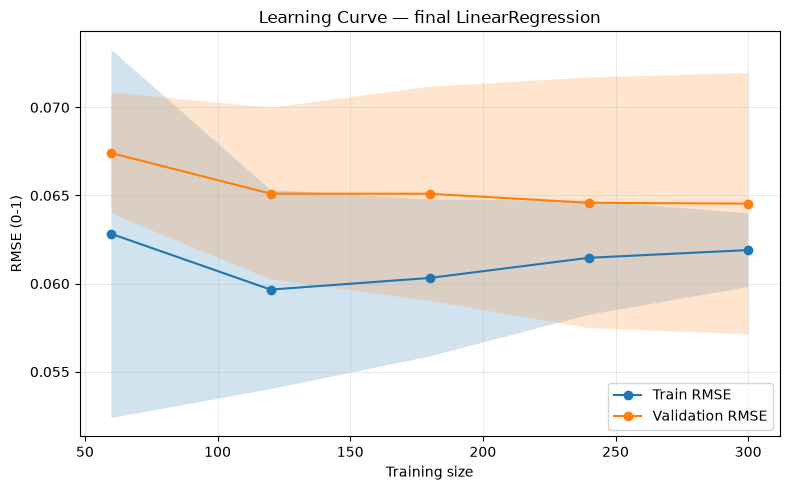

,Training size,Train RMSE mean,Train RMSE std,Validation RMSE mean,Validation RMSE std
0,60,0.062820,0.010449,0.067408,0.003438
1,120,0.059661,0.005651,0.065103,0.004873
2,180,0.060322,0.004453,0.065098,0.006079
3,240,0.061465,0.003234,0.064585,0.007107
4,300,0.061902,0.002094,0.064537,0.007414


In [14]:
learning_cv = KFold(n_splits=5, shuffle=True, random_state=42)
learning_sizes, learning_train_scores, learning_validation_scores = learning_curve(
    final_pipeline,
    X_train,
    y_train,
    cv=learning_cv,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 5),
    shuffle=True,
    random_state=42,
    n_jobs=1,
    error_score="raise",
)

learning_train_rmse = -learning_train_scores
learning_validation_rmse = -learning_validation_scores
learning_curve_summary = pd.DataFrame(
    {
        "Training size": learning_sizes,
        "Train RMSE mean": learning_train_rmse.mean(axis=1),
        "Train RMSE std": np.std(learning_train_rmse, axis=1, ddof=1),
        "Validation RMSE mean": learning_validation_rmse.mean(axis=1),
        "Validation RMSE std": np.std(learning_validation_rmse, axis=1, ddof=1),
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(learning_sizes, learning_curve_summary["Train RMSE mean"], marker="o", label="Train RMSE")
ax.fill_between(
    learning_sizes,
    learning_curve_summary["Train RMSE mean"] - learning_curve_summary["Train RMSE std"],
    learning_curve_summary["Train RMSE mean"] + learning_curve_summary["Train RMSE std"],
    alpha=0.2,
)
ax.plot(
    learning_sizes,
    learning_curve_summary["Validation RMSE mean"],
    marker="o",
    label="Validation RMSE",
)
ax.fill_between(
    learning_sizes,
    learning_curve_summary["Validation RMSE mean"] - learning_curve_summary["Validation RMSE std"],
    learning_curve_summary["Validation RMSE mean"] + learning_curve_summary["Validation RMSE std"],
    alpha=0.2,
)
ax.set_title(f"Learning Curve — final {final_model_name}")
ax.set_xlabel("Training size")
ax.set_ylabel("RMSE (0-1)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

display(learning_curve_summary.round(6))

## ⏱️ Scalability

The same complete Pipeline is evaluated with `return_times=True`. These measurements
describe this small dataset and must not be generalized to production scale.


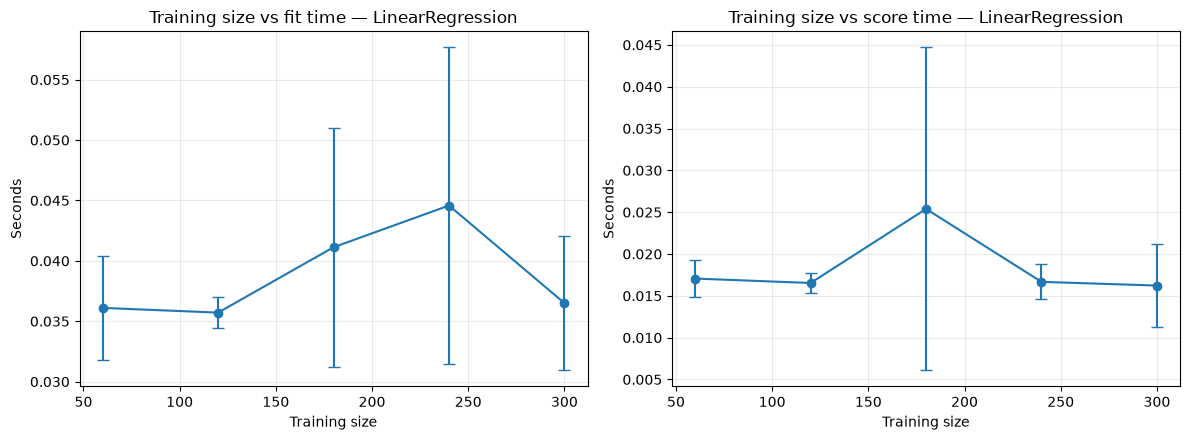

The dataset has only 471 unique observations; these timings are internal comparisons, not production scalability evidence.


,Training size,Fit time mean (s),Fit time std (s),Score time mean (s),Score time std (s)
0,60,0.036106,0.004307,0.017062,0.002239
1,120,0.035717,0.001282,0.016533,0.001176
2,180,0.041128,0.009894,0.025389,0.019299
3,240,0.044580,0.013086,0.016669,0.002097
4,300,0.036505,0.005569,0.016227,0.004951


In [15]:
scale_sizes, scale_train_scores, scale_validation_scores, fit_times, score_times = learning_curve(
    final_pipeline,
    X_train,
    y_train,
    cv=learning_cv,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 5),
    shuffle=True,
    random_state=42,
    return_times=True,
    n_jobs=1,
    error_score="raise",
)

scalability_summary = pd.DataFrame(
    {
        "Training size": scale_sizes,
        "Fit time mean (s)": fit_times.mean(axis=1),
        "Fit time std (s)": np.std(fit_times, axis=1, ddof=1),
        "Score time mean (s)": score_times.mean(axis=1),
        "Score time std (s)": np.std(score_times, axis=1, ddof=1),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].errorbar(
    scale_sizes,
    scalability_summary["Fit time mean (s)"],
    yerr=scalability_summary["Fit time std (s)"],
    marker="o",
    capsize=4,
)
axes[0].set_title(f"Training size vs fit time — {final_model_name}")
axes[0].set_xlabel("Training size")
axes[0].set_ylabel("Seconds")
axes[0].grid(alpha=0.25)
axes[1].errorbar(
    scale_sizes,
    scalability_summary["Score time mean (s)"],
    yerr=scalability_summary["Score time std (s)"],
    marker="o",
    capsize=4,
)
axes[1].set_title(f"Training size vs score time — {final_model_name}")
axes[1].set_xlabel("Training size")
axes[1].set_ylabel("Seconds")
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

print(
    "The dataset has only 471 unique observations; these timings are internal comparisons, not production scalability evidence."
)
display(scalability_summary.round(6))

## 💾 Serialize the complete Pipeline

The saved artifact contains preprocessing and the final practical estimator together. The
verification loads the artifact and compares predictions for a small `X_test` sample with
the predictions already generated by the original final Pipeline. It does not recalculate
Test metrics or use Test for any selection or tuning decision.


In [16]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_pipeline, MODEL_PATH)
assert MODEL_PATH.exists()

loaded_pipeline = joblib.load(MODEL_PATH)
feature_names = loaded_pipeline.named_steps["preprocessor"].get_feature_names_out()
original_sample_predictions = final_test_predictions[:5]
loaded_sample_predictions = loaded_pipeline.predict(X_test.iloc[:5])
assert np.allclose(original_sample_predictions, loaded_sample_predictions, rtol=1e-12, atol=1e-12)
assert isinstance(loaded_pipeline, Pipeline)
assert isinstance(loaded_pipeline.named_steps["model"], LinearRegression)
assert "preprocessor" in loaded_pipeline.named_steps
assert "model" in loaded_pipeline.named_steps

print(f"Serialized complete Pipeline: {MODEL_PATH}")
print("Serialized steps:", list(loaded_pipeline.named_steps))
print("Final feature names:", list(feature_names))
print("Original vs loaded predictions allclose: True")

Serialized complete Pipeline: /home/elkiruvi/Proyecto-Admisiones/models/05_model_selection_pipeline.joblib
Serialized steps: ['preprocessor', 'model']
Final feature names: ['numeric__GRE Score', 'numeric__TOEFL Score', 'numeric__CGPA', 'ordinal__University Rating', 'ordinal__SOP', 'ordinal__LOR', 'binary__Research']
Original vs loaded predictions allclose: True


## 🧠 Interpretation, analysis and recommendations

The practical final model is `LinearRegression`. Ridge remains in the analysis because it
obtained the lowest observed Outer CV RMSE, but the difference was minimal and the tests
did not establish statistical superiority. LinearRegression was selected before Test
because it offers practically equivalent predictive performance with lower tuning cost,
lower complexity and direct coefficient interpretability.

This is a predictive association analysis, not a causal analysis. The next Issue can use
the serialized Pipeline and its feature names to inspect coefficients, signs and magnitudes
without rebuilding preprocessing manually.

Historical limitation: Issue #3 used all 623 observations, including future Test rows, to
motivate CGPA and the CGPA heuristic. That limitation is documented here and is not
corrected retrospectively.


In [17]:
final_estimator = final_pipeline.named_steps["model"]
coefficients = pd.DataFrame(
    {
        "Feature": feature_names,
        "Coefficient": np.asarray(final_estimator.coef_).ravel(),
    }
).sort_values("Coefficient", key=np.abs, ascending=False)
print("LinearRegression coefficients (largest absolute values first):")
display(coefficients.round(6))

print("Conclusions:")
print("- Eight models across multiple methodological families were evaluated.")
print(
    f"- The academic RMSE filter retained {len(survivor_summary)} models and produced {len(finalist_names)} finalists."
)
print(
    f"- {best_observed_name} obtained the lowest observed Outer CV RMSE ({outer_means[best_observed_name]:.6f})."
)
print(
    f"- {final_model_name} achieved Outer CV RMSE {final_outer_cv_rmse:.6f}, practically equivalent to {best_observed_name} and better than the baseline {baseline_outer_rmse_mean:.6f}."
)
print(
    "- The statistical tests did not provide sufficient evidence of finalist superiority with five folds."
)
print(
    "- LinearRegression was selected for parsimony, lower tuning cost and interpretability, not because it had the lowest RMSE."
)
print(
    f"- Final Test RMSE {test_rmse:.6f} is below the historical baseline Test RMSE {historical_baseline_test_rmse:.4f}."
)
print(
    "- The Train/CV/Test values and learning curve do not provide strong evidence of high variance or high bias."
)
print(
    "- The dataset is small, five folds limit statistical power, and the EDA has a historical informational leakage limitation."
)

print("Recommendations:")
print(
    "- Keep LinearRegression as the final model for this dataset and preserve its complete Pipeline."
)
print("- Keep Ridge as a regularized alternative if future features increase multicollinearity.")
print("- Evaluate the EDA interactions in a later feature-engineering/modeling Issue.")
print(
    "- Perform formal coefficient interpretation in Issue #7 using feature_names and the serialized Pipeline."
)
print("- Reassess coefficients and stability when new data becomes available.")

LinearRegression coefficients (largest absolute values first):


,Feature,Coefficient
2,numeric__CGPA,0.069831
6,binary__Research,0.024351
1,numeric__TOEFL Score,0.022785
0,numeric__GRE Score,0.021420
5,ordinal__LOR,0.017805
4,ordinal__SOP,-0.000155
3,ordinal__University Rating,0.000045


Conclusions:
- Eight models across multiple methodological families were evaluated.
- The academic RMSE filter retained 5 models and produced 3 finalists.
- Ridge obtained the lowest observed Outer CV RMSE (0.064376).
- LinearRegression achieved Outer CV RMSE 0.064463, practically equivalent to Ridge and better than the baseline 0.090239.
- The statistical tests did not provide sufficient evidence of finalist superiority with five folds.
- LinearRegression was selected for parsimony, lower tuning cost and interpretability, not because it had the lowest RMSE.
- Final Test RMSE 0.068500 is below the historical baseline Test RMSE 0.0919.
- The Train/CV/Test values and learning curve do not provide strong evidence of high variance or high bias.
- The dataset is small, five folds limit statistical power, and the EDA has a historical informational leakage limitation.
Recommendations:
- Keep LinearRegression as the final model for this dataset and preserve its complete Pipeline.
- Keep Ridge 

## 📖 References

- `data/02_intermediate/Admission_Predict.parquet`
- `notebooks/4-feat_eng/04.1-SCO_feature_engineering-2026_08_19.ipynb`
- `notebooks/5-models/05.1-SCO_baseline_model-2026_08_19.ipynb`
- `notebooks/3-analysis/03.2-SCO_bivariate_analysis-2026_08_19.ipynb`
- `notebooks/3-analysis/03.3-SCO_multivariate_analysis-2026_08_19.ipynb`
- `notebooks/README.md`
- `AGENTS.md` (project operating rules; not modified or included in this Issue)
- scikit-learn documentation: `Pipeline`, `ColumnTransformer`, `cross_validate`,
  `GridSearchCV`, `learning_curve`
- scipy documentation: `friedmanchisquare`, `wilcoxon`
- Course reference: <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/6-model_selection/>
